<a href="https://colab.research.google.com/github/Frederik-Roeckle/GenderSentimentGermanParliament/blob/master/TrainingsloopBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers[torch] datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate
import numpy as np
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
drive.mount('/content/drive')

# train_data = '/content/drive/MyDrive/Colab Notebooks/GermanDistilBERT/zwischenfragen_annotations.csv'
train_data = '/content/drive/MyDrive/Colab Notebooks/GermanDistilBERT/output_gender_masked.csv'

df = pd.read_csv(train_data)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Unnamed: 0    source_file  \
0           0  BT_02_064.xml   
1           1  BT_02_070.xml   
2           2  BT_02_070.xml   
3           3  BT_02_070.xml   
4           4  BT_02_070.xml   

                                  permission_request   permission_answer  \
0  Herr Abgeordneter, gestatten Sie eine Zwischen...                 Ja.   
1  Herr Abgeordneter, gestatten Sie eine Zwischen...  Gern! Bitte schön!   
2  Herr Abgeordneter, gestatten Sie eine Zwischen...        Bitte schön!   
3  Herr Abgeordneter, gestatten Sie eine Zwischen...               Gern!   
4  Gestatten Sie eine Zwischenfrage, Herr Bundesk...                 Ja!   

  permission_granted                                 zwischenfrage_text  \
0               True  Gestatten Sie, Herr Kollege Schloß, eine Frage...   
1               True  Herr Kollege Erler, gestatten Sie mir bitte ei...

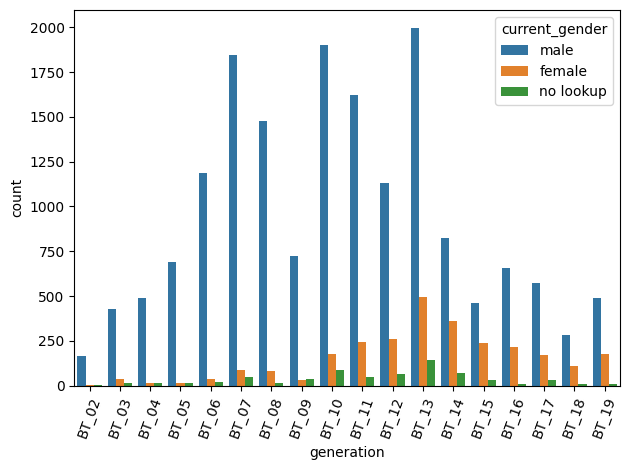

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df["generation"] = df["source_file"].str[:5]
a = df[["generation", "current_gender"]].value_counts().to_frame().sort_values("generation")
sns.barplot(a, x="generation", y="count", hue="current_gender")

plt.xticks(rotation=70)
plt.tight_layout()

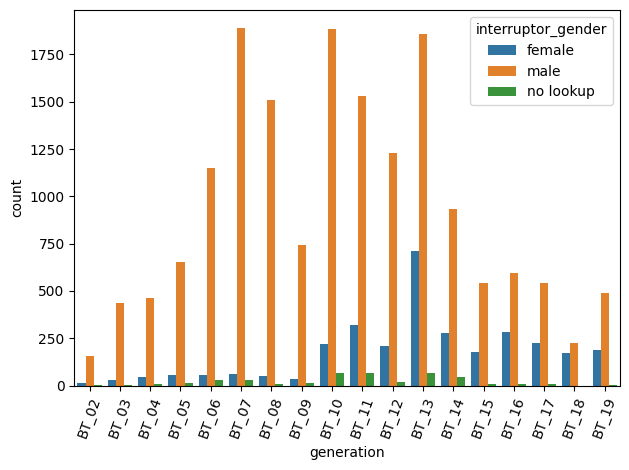

In [ ]:
b = df[["generation", "interruptor_gender"]].value_counts().to_frame().sort_values("generation")
sns.barplot(b, x="generation", y="count", hue="interruptor_gender")

plt.xticks(rotation=70)
plt.tight_layout()

In [ ]:
zwischenfrage = False
gender_prediction = True


if zwischenfrage:
  texts = df.zwischenfrage
  labels = df.annotation

  raw_dataset = Dataset.from_dict({"text": texts, "label": labels})
  print(raw_dataset)

  # Split into Train and Test (80/20)
  dataset_dict = raw_dataset.train_test_split(test_size=0.2)

if gender_prediction:
  df.dropna(subset=["zwischenfrage_text_masked_combined"], inplace=True)
  df = df.loc[df["current_gender"] != "no lookup"]
  df.current_gender = df.current_gender.replace("male", 0)
  df.current_gender = df.current_gender.replace("female", 1)

  # temporal split over 4 quantilles

  subset_2_5_gen = ["BT_02", "BT_03", "BT_04", "BT_05"]
  subset_6_10_gen = ["BT_06", "BT_07", "BT_08", "BT_09", "BT_10"]
  subset_11_14_gen = ["BT_11", "BT_12", "BT_13", "BT_14"]
  subset_15_19_gen = ["BT_15", "BT_16", "BT_17", "BT_18", "BT_19"]

  df_subset_2_5 = df.loc[df.generation.isin(subset_2_5_gen)]
  df_subset_6_10 = df.loc[df.generation.isin(subset_6_10_gen)]
  df_subset_11_14 = df.loc[df.generation.isin(subset_11_14_gen)]
  df_subset_15_19 = df.loc[df.generation.isin(subset_15_19_gen)]


  texts_2_5 = df_subset_2_5.zwischenfrage_text_masked_combined
  labels_2_5 = df_subset_2_5.current_gender
  dataset_2_5 = Dataset.from_dict({"text": texts_2_5, "label": labels_2_5})

  texts_6_10 = df_subset_6_10.zwischenfrage_text_masked_combined
  labels_6_10 = df_subset_6_10.current_gender
  dataset_6_10 = Dataset.from_dict({"text": texts_6_10, "label": labels_6_10})

  texts_11_14 = df_subset_11_14.zwischenfrage_text_masked_combined
  labels_11_14 = df_subset_11_14.current_gender
  dataset_11_14 = Dataset.from_dict({"text": texts_11_14, "label": labels_11_14})

  texts_15_19 = df_subset_15_19.zwischenfrage_text_masked_combined
  labels_15_19 = df_subset_15_19.current_gender
  dataset_15_19 = Dataset.from_dict({"text": texts_15_19, "label": labels_15_19})


  # Split into Train and Test (80/20)
  # dataset split 2_5
  train_2_5, test_2_5 = train_test_split(
    df_subset_2_5[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_2_5['current_gender']
  )
  # train_2_5_ds = Dataset.from_pandas(train_2_5.reset_index(drop=True))
  train_2_5_ds = Dataset.from_dict({"text": train_2_5.zwischenfrage_text_masked_combined, "label": train_2_5.current_gender})
  test_2_5_ds = Dataset.from_dict({"text": test_2_5.zwischenfrage_text_masked_combined, "label": test_2_5.current_gender})
  dataset_dict_2_5 = DatasetDict({
      'train': train_2_5_ds,
      'test': test_2_5_ds
  })


  # dataset split 6_10
  train_6_10, test_6_10 = train_test_split(
    df_subset_6_10[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_6_10['current_gender']
  )
  train_6_10_ds = Dataset.from_dict({"text": train_6_10.zwischenfrage_text_masked_combined, "label": train_6_10.current_gender})
  test_6_10_ds = Dataset.from_dict({"text": test_6_10.zwischenfrage_text_masked_combined, "label": test_6_10.current_gender})
  dataset_dict_6_10 = DatasetDict({
      'train': train_6_10_ds,
      'test': test_6_10_ds
  })


  # dataset split 11_14
  train_11_14, test_11_14 = train_test_split(
    df_subset_11_14[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_11_14['current_gender']
  )
  train_11_14_ds = Dataset.from_dict({"text": train_11_14.zwischenfrage_text_masked_combined, "label": train_11_14.current_gender})
  test_11_14_ds =  Dataset.from_dict({"text": test_11_14.zwischenfrage_text_masked_combined, "label": test_11_14.current_gender})
  dataset_dict_11_14 = DatasetDict({
      'train': train_11_14_ds,
      'test': test_11_14_ds
  })


  # dataset split 15_19
  train_15_19, test_15_19 = train_test_split(
    df_subset_15_19[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_15_19['current_gender']
  )
  train_15_19_ds = Dataset.from_dict({"text": train_15_19.zwischenfrage_text_masked_combined, "label": train_15_19.current_gender})
  test_15_19_ds = Dataset.from_dict({"text": test_15_19.zwischenfrage_text_masked_combined, "label": test_15_19.current_gender})
  dataset_dict_15_19 = DatasetDict({
      'train': train_15_19_ds,
      'test': test_15_19_ds
  })

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

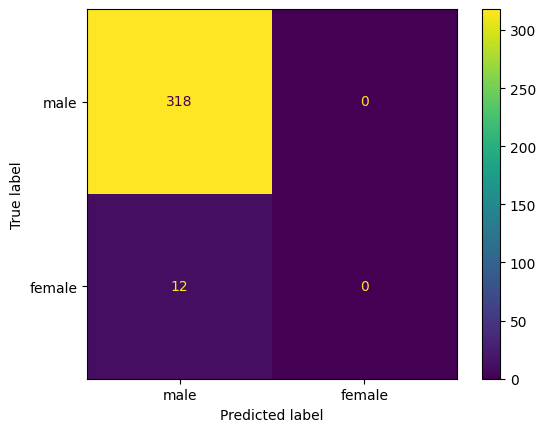

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        male       0.96      1.00      0.98       318
      female       0.00      0.00      0.00        12

    accuracy                           0.96       330
   macro avg       0.48      0.50      0.49       330
weighted avg       0.93      0.96      0.95       330



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

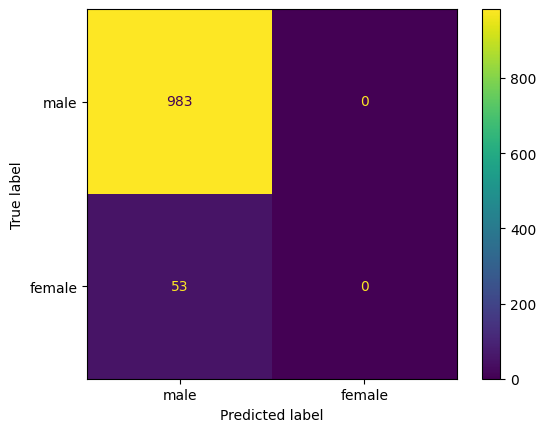

              precision    recall  f1-score   support

        male       0.95      1.00      0.97       983
      female       0.00      0.00      0.00        53

    accuracy                           0.95      1036
   macro avg       0.47      0.50      0.49      1036
weighted avg       0.90      0.95      0.92      1036



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

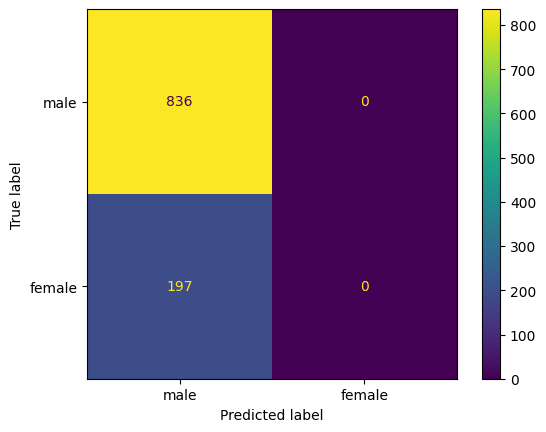

              precision    recall  f1-score   support

        male       0.81      1.00      0.89       836
      female       0.00      0.00      0.00       197

    accuracy                           0.81      1033
   macro avg       0.40      0.50      0.45      1033
weighted avg       0.65      0.81      0.72      1033



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

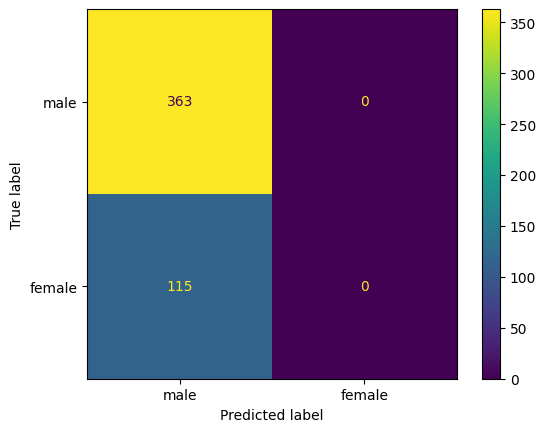

              precision    recall  f1-score   support

        male       0.76      1.00      0.86       363
      female       0.00      0.00      0.00       115

    accuracy                           0.76       478
   macro avg       0.38      0.50      0.43       478
weighted avg       0.58      0.76      0.66       478



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 2_5
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_2_5",
    tokenizer="./my_custom_german_model_2_5"
)
X = list(dataset_dict_2_5["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("male", "0").replace("female", "1")) for p in predictions]
cm = confusion_matrix(dataset_dict_2_5["test"]["label"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_2_5["test"]["label"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))



# 6_10
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_6_10",
    tokenizer="./my_custom_german_model_6_10"
)
X = list(dataset_dict_6_10["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("male", "0").replace("female", "1")) for p in predictions]
cm = confusion_matrix(dataset_dict_6_10["test"]["label"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_6_10["test"]["label"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))


# 11_14
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_11_14",
    tokenizer="./my_custom_german_model_11_14"
)
X = list(dataset_dict_11_14["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("male", "0").replace("female", "1")) for p in predictions]
cm = confusion_matrix(dataset_dict_11_14["test"]["label"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_11_14["test"]["label"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))


# 15_19
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_15_19",
    tokenizer="./my_custom_german_model_15_19"
)
X = list(dataset_dict_15_19["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("male", "0").replace("female", "1")) for p in predictions]
cm = confusion_matrix(dataset_dict_15_19["test"]["label"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_15_19["test"]["label"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))

In [ ]:
model_name = "distilbert/distilbert-base-german-cased"
num_labels = 2

def tokenize_function(examples):
      return tokenizer(examples["text"], truncation=True, padding=True)

def compute_metrics(eval_pred):
      logits, labels = eval_pred
      predictions = np.argmax(logits, axis=-1)
      return metric.compute(predictions=predictions, references=labels)

for name, dataset_dict in {"2_5": dataset_dict_2_5,
                           "6_10": dataset_dict_6_10,
                           "11_14": dataset_dict_11_14,
                           "15_19": dataset_dict_15_19}.items():
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
  data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

  if gender_prediction:
    id2label = {0: "male", 1: "female"}
    label2id = {"male": 0, "female": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )

  metric = evaluate.load("f1")

  training_args = TrainingArguments(
    output_dir=f"./german-binary-classifier_{name}",
    learning_rate=1e-5,
    per_device_train_batch_size=64,
    num_train_epochs=10, # Slightly more epochs for smaller custom datasets
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
  )

  trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
  )

  trainer.train()
  trainer.save_model(f"./my_custom_german_model_{name}")


Map:   0%|          | 0/1317 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/270M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
model_name = "distilbert/distilbert-base-german-cased"
num_labels = 2

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/1317 [00:00<?, ? examples/s]

KeyError: 'text'

In [ ]:

if zwischenfrage:
  id2label = {0: "NEGATIVE", 1: "POSITIVE"}
  label2id = {"NEGATIVE": 0, "POSITIVE": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )
  for param in model.distilbert.parameters():
      param.requires_grad = False


if gender_prediction:
  id2label = {0: "male", 1: "female"}
  label2id = {"male": 0, "female": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )
  # no freezing loops of weights

model.safetensors:   0%|          | 0.00/270M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
metric = evaluate.load("f1") # F1-score is often better for binary tasks

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
training_args = TrainingArguments(
    output_dir="./german-binary-classifier",
    learning_rate=1e-5,
    per_device_train_batch_size=64,
    num_train_epochs=10, # Slightly more epochs for smaller custom datasets
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()
trainer.save_model("./my_custom_german_model")

Epoch,Training Loss,Validation Loss,F1
1,No log,0.364753,0.000000
2,No log,0.358245,0.005464
3,0.367117,0.357520,0.086735
4,0.367117,0.363010,0.121065
5,0.367117,0.370297,0.227799
6,0.310960,0.379311,0.257812
7,0.310960,0.388094,0.261649
8,0.310960,0.399279,0.272572
9,0.255966,0.411544,0.282642
10,0.255966,0.409132,0.267559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Inference Test
from transformers import pipeline

pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model",
    tokenizer="./my_custom_german_model"
)

# 2. Predict on a single sentence
text = "Ich nehme die Zwischenfrage gerne an."
result = pipe(text)
print(f"Result: {result}")

# 3. Predict on a list of sentences
sequences = [
    "Dafür habe ich nun leider keine Zeit.",
    "Noch nicht.",
    "Beim nächsten Mal.",
    "Ja, sehr gerne Frau Kollegin."
]
results = pipe(sequences)

for text, res in zip(sequences, results):
    print(f"\nText: {text}")
    print(f"Label: {res['label']}, Score: {res['score']:.4f}")

OSError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './my_custom_german_model'.

## TF-IDF approach

In [ ]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score


# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# 3. Create the Pipeline
# We use German stop words because common words like "der, die, das"
# carry no meaning for classification.
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),   # Look at single words AND pairs (e.g., "nicht gut")
        max_features=1000,    # Limit features so we don't overfit
        stop_words=None       # We'll handle German stops below or keep them
    )),
    ('clf', LogisticRegression(C=1.0)), # C is regularization; lower C = less overfitting
])

# 4. Train
text_clf.fit(X_train, y_train)

# 5. Evaluate
predictions = text_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions))

# 6. Save the model
joblib.dump(text_clf, 'german_tfidf_model.pkl')

Accuracy: 86.82%
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      2499
           1       0.00      0.00      0.00       377

    accuracy                           0.87      2876
   macro avg       0.43      0.50      0.46      2876
weighted avg       0.75      0.87      0.81      2876



['german_tfidf_model.pkl']

In [ ]:
# For Inference
import joblib

# Load the model
model = joblib.load('german_tfidf_model.pkl')

# Predict
new_texts = [
    "Dafür habe ich nun leider keine Zeit.",
    "Noch nicht.",
    "Nein, Beim nächsten Mal.",
    "Ja, oder nein, nein!.",
    "Bitte, Herr Kollege",
    "An Sie, Frau Kollegin. Familie, Frauen, Erziehung, Haushalt, Geburt, Emotional, Weiblich, schwach"
]
preds = model.predict(new_texts)
probs = model.predict_proba(new_texts) # Returns probability for [Class 0, Class 1]

for text, p, prob in zip(new_texts, preds, probs):
    print(f"Text: {text} | Label: {p} | Confidence: {max(prob):.2%}")

Text: Dafür habe ich nun leider keine Zeit. | Label: 0 | Confidence: 88.80%
Text: Noch nicht. | Label: 0 | Confidence: 87.84%
Text: Nein, Beim nächsten Mal. | Label: 0 | Confidence: 92.79%
Text: Ja, oder nein, nein!. | Label: 0 | Confidence: 87.18%
Text: Bitte, Herr Kollege | Label: 0 | Confidence: 80.66%
Text: An Sie, Frau Kollegin. Familie, Frauen, Erziehung, Haushalt, Geburt, Emotional, Weiblich, schwach | Label: 0 | Confidence: 50.07%
